USO → USL: peak lag = 0 | corr = 0.914
USO → PVL: peak lag = 0 | corr = 0.230
USO → PRT: peak lag = 0 | corr = 0.383
USL → PVL: peak lag = 0 | corr = 0.268
USL → PRT: peak lag = 0 | corr = 0.431
PVL → PRT: peak lag = 0 | corr = 0.215
USO → TPL: peak lag = 0 | corr = 0.469
USL → TPL: peak lag = 0 | corr = 0.501
PVL → TPL: peak lag = 0 | corr = 0.243
PRT → TPL: peak lag = 0 | corr = 0.327
USO → PBT: peak lag = 0 | corr = 0.374
USL → PBT: peak lag = 0 | corr = 0.375
PVL → PBT: peak lag = 0 | corr = 0.274
PRT → PBT: peak lag = 0 | corr = 0.298
TPL → PBT: peak lag = 0 | corr = 0.384
USO → PR: peak lag = 0 | corr = 0.480
USL → PR: peak lag = 0 | corr = 0.477
PVL → PR: peak lag = 0 | corr = 0.236
PRT → PR: peak lag = 0 | corr = 0.293
TPL → PR: peak lag = 0 | corr = 0.492
PBT → PR: peak lag = 0 | corr = 0.338


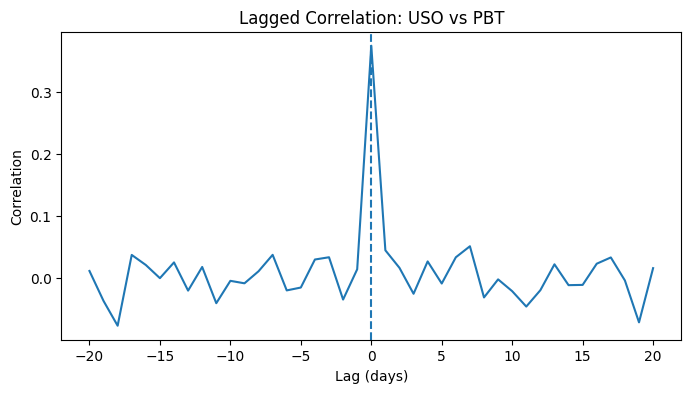

In [38]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ["USL", "PVL", "PRT", "USO", "TPL", "PBT", "PR"]

# ── download safely ─────────────────────────
prices = pd.DataFrame()

for t in tickers:
    df = yf.download(
        t,
        period="10y",
        interval="1d",
        auto_adjust=True,
        progress=False,
        threads=False
    )
    prices[t] = df["Close"]

prices = prices.dropna()

# ── returns ─────────────────────────
returns = np.log(prices).diff().dropna()


# ── lag correlation function ─────────────────────────
def lag_corr(x, y, max_lag=20):
    lags = range(-max_lag, max_lag + 1)
    corrs = []

    for lag in lags:
        corr = x.corr(y.shift(lag))
        corrs.append(corr)

    return pd.Series(corrs, index=lags)


# ── analyze pairs ─────────────────────────
pairs = [
    ("USO", "USL"),
    ("USO", "PVL"),
    ("USO", "PRT"),
    ("USL", "PVL"),
    ("USL", "PRT"),
    ("PVL", "PRT"),
    ("USO", "TPL"),
    ("USL", "TPL"),
    ("PVL", "TPL"),
    ("PRT", "TPL"),
    ("USO", "PBT"),
    ("USL", "PBT"),
    ("PVL", "PBT"),
    ("PRT", "PBT"),
    ("TPL", "PBT"),
    ("USO", "PR"),
    ("USL", "PR"),
    ("PVL", "PR"),
    ("PRT", "PR"),
    ("TPL", "PR"),
    ("PBT", "PR")
]

for a, b in pairs:
    corr_series = lag_corr(returns[a], returns[b])

    peak_lag = corr_series.idxmax()
    peak_corr = corr_series.max()

    print(f"{a} → {b}: peak lag = {peak_lag} | corr = {peak_corr:.3f}")


# ── example plot ─────────────────────────
pair = ("USO", "PBT")
corr_series = lag_corr(returns[pair[0]], returns[pair[1]])

plt.figure(figsize=(8,4))
corr_series.plot()
plt.axvline(0, linestyle="--")
plt.title(f"Lagged Correlation: {pair[0]} vs {pair[1]}")
plt.xlabel("Lag (days)")
plt.ylabel("Correlation")
plt.show()

USO → USL: peak lag = 0 days | corr = 0.922
USO → PVL: peak lag = 0 days | corr = 0.408
USO → PRT: peak lag = 0 days | corr = 0.518
USL → PVL: peak lag = 0 days | corr = 0.496
USL → PRT: peak lag = 0 days | corr = 0.541


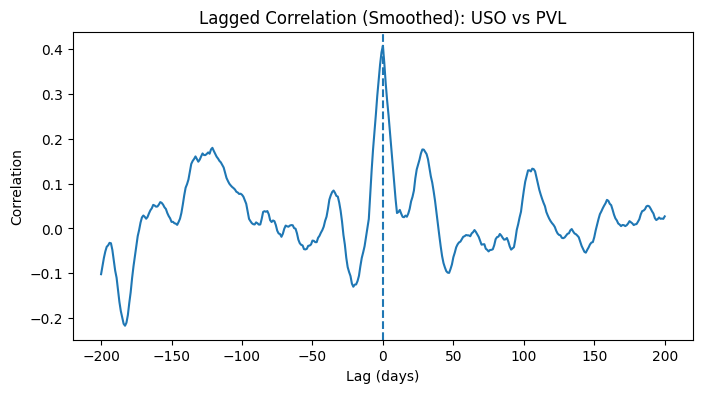

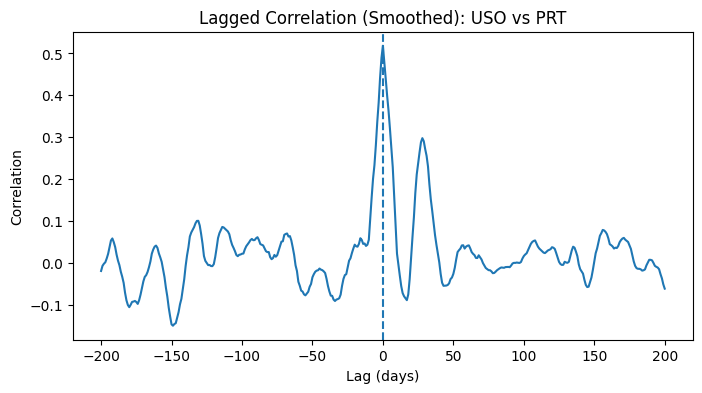

In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ["USL", "PVL", "PRT", "USO"]

# ── Download data ─────────────────────────
prices = pd.DataFrame()

for t in tickers:
    df = yf.download(
        t,
        period="10y",
        interval="1d",
        auto_adjust=True,
        progress=False,
        threads=False
    )
    prices[t] = df["Close"]

prices = prices.dropna()

# ── Compute log returns ───────────────────
returns = np.log(prices).diff().dropna()

# ── Smooth returns (5-day moving average) ─
smooth_returns = returns.rolling(10).mean().dropna()


# ── Lag correlation function ──────────────
def lag_corr(x, y, max_lag=200):
    lags = range(-max_lag, max_lag + 1)
    corrs = []

    for lag in lags:
        corrs.append(x.corr(y.shift(lag)))

    return pd.Series(corrs, index=lags)


# ── Analyze pairs ─────────────────────────
pairs = [
    ("USO", "USL"),
    ("USO", "PVL"),
    ("USO", "PRT"),
    ("USL", "PVL"),
    ("USL", "PRT"),
]

for a, b in pairs:
    corr_series = lag_corr(smooth_returns[a], smooth_returns[b], max_lag=20)

    peak_lag = corr_series.idxmax()
    peak_corr = corr_series.max()

    print(f"{a} → {b}: peak lag = {peak_lag} days | corr = {peak_corr:.3f}")


# ── Plot example ─────────────────────────
pair = ("USO", "PVL")
corr_series = lag_corr(smooth_returns[pair[0]], smooth_returns[pair[1]])

plt.figure(figsize=(8,4))
corr_series.plot()
plt.axvline(0, linestyle="--")
plt.title(f"Lagged Correlation (Smoothed): {pair[0]} vs {pair[1]}")
plt.xlabel("Lag (days)")
plt.ylabel("Correlation")
plt.show()

# ── Plot example ─────────────────────────
pair = ("USO", "PRT")
corr_series = lag_corr(smooth_returns[pair[0]], smooth_returns[pair[1]])

plt.figure(figsize=(8,4))
corr_series.plot()
plt.axvline(0, linestyle="--")
plt.title(f"Lagged Correlation (Smoothed): {pair[0]} vs {pair[1]}")
plt.xlabel("Lag (days)")
plt.ylabel("Correlation")
plt.show()

/var/folders/jn/h8_6ldvx1wz2fwvbpv9k_nmh0000gn/T/ipykernel_20221/652347427.py:37: RuntimeWarning: invalid value encountered in divide
  lag = phase / (2 * np.pi * f)
/var/folders/jn/h8_6ldvx1wz2fwvbpv9k_nmh0000gn/T/ipykernel_20221/652347427.py:41: RuntimeWarning: divide by zero encountered in divide
  cycle_days = 1 / f


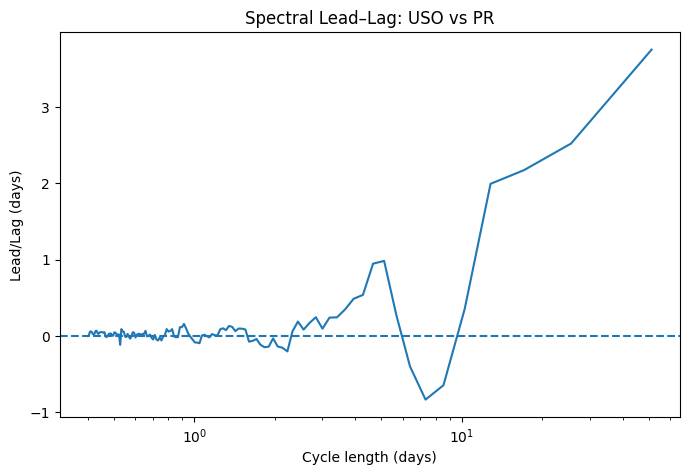

In [40]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import csd, coherence

tickers = ["USO", "PR"]

# ── download prices ─────────────────────────
prices = pd.DataFrame()

for t in tickers:
    df = yf.download(t, period="20y", progress=False, auto_adjust=True)
    prices[t] = df["Close"]

prices = prices.dropna()

# ── log prices (macro signals work better in levels) ──
logp = np.log(prices)

# detrend
logp = logp - logp.rolling(60).mean()
logp = logp.dropna()

x = logp["USO"]
y = logp["PR"]

# ── spectral cross density ─────────────────────────
fs = 5  # daily frequency

f, Pxy = csd(x, y, fs=fs, nperseg=256)

# phase
phase = np.angle(Pxy)

# convert phase → lag in days
lag = phase / (2 * np.pi * f)
lag[0] = 0  # avoid divide-by-zero

# ── plot lead-lag by cycle length ─────────────────
cycle_days = 1 / f

plt.figure(figsize=(8,5))
plt.plot(cycle_days, lag)
plt.xscale("log")
plt.xlabel("Cycle length (days)")
plt.ylabel("Lead/Lag (days)")
plt.title("Spectral Lead–Lag: USO vs PR")
plt.axhline(0, linestyle="--")
plt.show()

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt

# ── download data ─────────────────────────
tickers = ["USO", "PVL"]
prices = pd.DataFrame()

for t in tickers:
    df = yf.download(t, period="5y", progress=False, auto_adjust=True)
    prices[t] = df["Close"]

prices = prices.dropna()

# ── log prices and detrend ────────────────
logp = np.log(prices)
logp = logp - logp.rolling(60).mean()
logp = logp.dropna()

x = logp["USO"].values
y = logp["PVL"].values

# ── wavelet transform ─────────────────────
scales = np.arange(2, 200)   # cycle lengths (days)

Wx, _ = pywt.cwt(x, scales, 'cmor')
Wy, _ = pywt.cwt(y, scales, 'cmor')

# cross-wavelet phase
Wxy = Wx * np.conj(Wy)
phase = np.angle(Wxy)

# convert phase → lead/lag (days)
lag = phase * scales[:, None] / (2*np.pi)

# ── plot heatmap ──────────────────────────
plt.figure(figsize=(10,6))

plt.imshow(
    lag,
    aspect='auto',
    cmap='RdBu',
    extent=[0, len(x), scales[-1], scales[0]]
)

plt.colorbar(label="Lead / Lag (days)")
plt.xlabel("Time")
plt.ylabel("Cycle length (days)")
plt.title("Time–Frequency Lead–Lag: USO vs PVL")

plt.show()

/Users/kavitakar/pookieMax/venv/lib/python3.12/site-packages/pywt/_cwt.py:113: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)


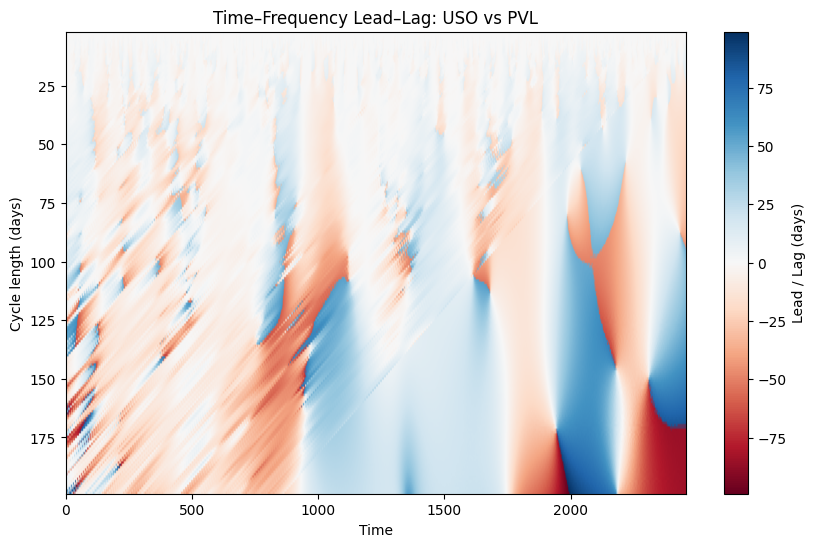

In [43]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt

# ── download data ─────────────────────────
tickers = ["USO", "PVL"]
prices = pd.DataFrame()

for t in tickers:
    df = yf.download(t, period="10y", progress=False, auto_adjust=True)
    prices[t] = df["Close"]

prices = prices.dropna()

# ── log prices and detrend ────────────────
logp = np.log(prices)
logp = logp - logp.rolling(60).mean()
logp = logp.dropna()

x = logp["USO"].values
y = logp["PVL"].values

# ── wavelet transform ─────────────────────
scales = np.arange(2, 200)   # cycle lengths (days)

Wx, _ = pywt.cwt(x, scales, 'cmor')
Wy, _ = pywt.cwt(y, scales, 'cmor')

# cross-wavelet phase
Wxy = Wx * np.conj(Wy)
phase = np.angle(Wxy)

# convert phase → lead/lag (days)
lag = phase * scales[:, None] / (2*np.pi)

# ── plot heatmap ──────────────────────────
plt.figure(figsize=(10,6))

plt.imshow(
    lag,
    aspect='auto',
    cmap='RdBu',
    extent=[0, len(x), scales[-1], scales[0]]
)

plt.colorbar(label="Lead / Lag (days)")
plt.xlabel("Time")
plt.ylabel("Cycle length (days)")
plt.title("Time–Frequency Lead–Lag: USO vs PVL")

plt.show()

In [57]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -----------------------------
# download data
# -----------------------------
tickers = ["USO", "PVL"]

prices = yf.download(
    tickers,
    period="15y",
    auto_adjust=True,
    progress=False
)["Close"].dropna()

returns = np.log(prices).diff().dropna()

oil = returns["USO"]
pvl = returns["PVL"]

# -----------------------------
# parameters
# -----------------------------
window = 252
max_horizon = 126
step = 5

horizons = np.arange(5, max_horizon + 1, step)

# -----------------------------
# compute predictive t-stats
# -----------------------------
max_h = horizons.max()
time_points = range(window, len(oil) - max_h)

heatmap = []

for h in horizons:

    future_ret = pvl.shift(-h).rolling(h).sum()
    row = []

    for i in time_points:

        x = oil.iloc[i-window:i]
        y = future_ret.iloc[i-window:i]

        valid = ~(x.isna() | y.isna())
        x = x[valid]
        y = y[valid]

        if len(x) < 30:
            row.append(np.nan)
            continue

        r = np.corrcoef(x, y)[0,1]
        r = np.clip(r, -0.9999, 0.9999)

        t_stat = r * np.sqrt((len(x)-2) / (1-r**2))
        row.append(t_stat)

    heatmap.append(row)

heatmap = np.array(heatmap)

# -----------------------------
# smooth signal
# -----------------------------
heatmap = pd.DataFrame(heatmap).rolling(5, axis=1).mean().values

# -----------------------------
# hide insignificant values
# -----------------------------
heatmap[np.abs(heatmap) < 2] = np.nan

# -----------------------------
# convert time indices → dates
# -----------------------------
dates = returns.index[list(time_points)]
date_nums = mdates.date2num(dates)

# -----------------------------
# plot
# -----------------------------
plt.figure(figsize=(12,6))

plt.imshow(
    heatmap,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-4,
    vmax=4,
    origin="lower",
    extent=[date_nums[0], date_nums[-1], horizons[0], horizons[-1]]
)

plt.colorbar(label="Predictive t-stat (USO → future PVL)")

ax = plt.gca()
ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# highlight the 2–4 month window
plt.axhline(40, linestyle="--", color="black", alpha=0.4)
plt.axhline(80, linestyle="--", color="black", alpha=0.4)

plt.xlabel("Date")
plt.ylabel("Prediction Horizon (days)")
plt.title("Predictive Relationship: USO → Future PVL Returns")

plt.tight_layout()
plt.show()

TypeError: NDFrame.rolling() got an unexpected keyword argument 'axis'

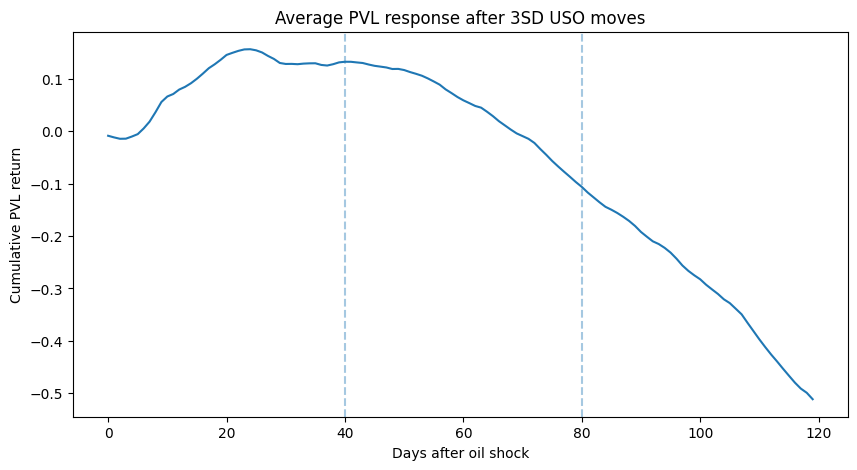

In [54]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# download data
# -----------------------------
tickers = ["USO", "PVL"]

prices = yf.download(
    tickers,
    period="10y",
    auto_adjust=True,
    progress=False
)["Close"].dropna()

returns = np.log(prices).diff().dropna()

oil = returns["USO"]
pvl = returns["PVL"]

# -----------------------------
# define oil shock
# -----------------------------
lookback = 20  # ~1 month move
oil_move = oil.rolling(lookback).sum()

threshold = 3 * oil_move.std()

events = oil_move[oil_move.abs() > threshold].index

# -----------------------------
# PVL response after events
# -----------------------------
max_horizon = 120  # ~6 months
responses = []

for h in range(max_horizon):

    future = pvl.shift(-h)

    vals = []

    for d in events:
        if d in future.index:
            r = future.loc[d]
            if not np.isnan(r):
                vals.append(r)

    responses.append(np.mean(vals))

responses = np.array(responses)

# -----------------------------
# cumulative response
# -----------------------------
cum_response = np.cumsum(responses)

# -----------------------------
# plot
# -----------------------------
plt.figure(figsize=(10,5))

plt.plot(cum_response)

plt.axvline(40, linestyle="--", alpha=0.4)
plt.axvline(80, linestyle="--", alpha=0.4)

plt.xlabel("Days after oil shock")
plt.ylabel("Cumulative PVL return")
plt.title("Average PVL response after 3SD USO moves")

plt.show()

In [17]:
from scipy.signal import butter, filtfilt
import numpy as np

def lowpass(series, cutoff_days=60):
    fs = 1  # daily data
    cutoff = 1 / cutoff_days
    b, a = butter(4, cutoff/(fs/2), btype='low')
    return filtfilt(b, a, series)

uso_macro = lowpass(np.log(prices["USO"]))
pvl_macro = lowpass(np.log(prices["PVL"]))

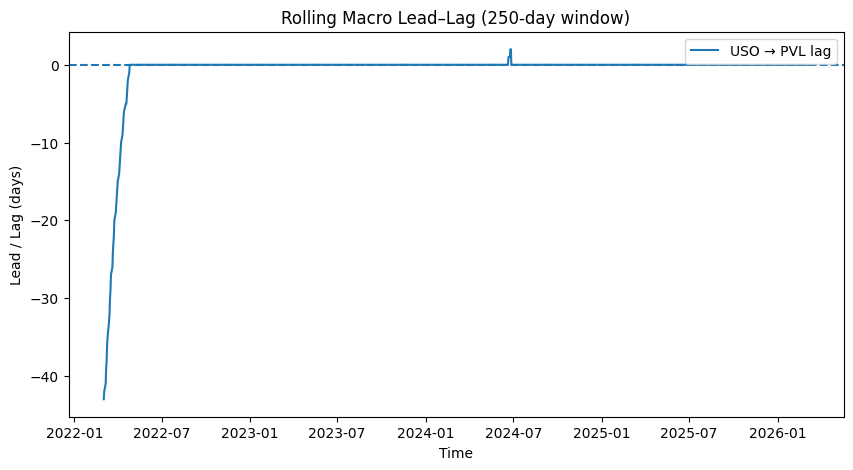

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
window = 250
lags = []

for i in range(window, len(uso_macro)):
    corr = np.correlate(
        uso_macro[i-window:i],
        pvl_macro[i-window:i],
        mode="full"
    )
    lag = np.argmax(corr) - (window-1)
    lags.append(lag)
# convert to pandas series aligned with dates
lag_series = pd.Series(
    lags,
    index=prices.index[window:]
)

plt.figure(figsize=(10,5))

plt.plot(lag_series, label="USO → PVL lag")
plt.axhline(0, linestyle="--")

plt.ylabel("Lead / Lag (days)")
plt.xlabel("Time")
plt.title("Rolling Macro Lead–Lag (250-day window)")
plt.legend()

plt.show()

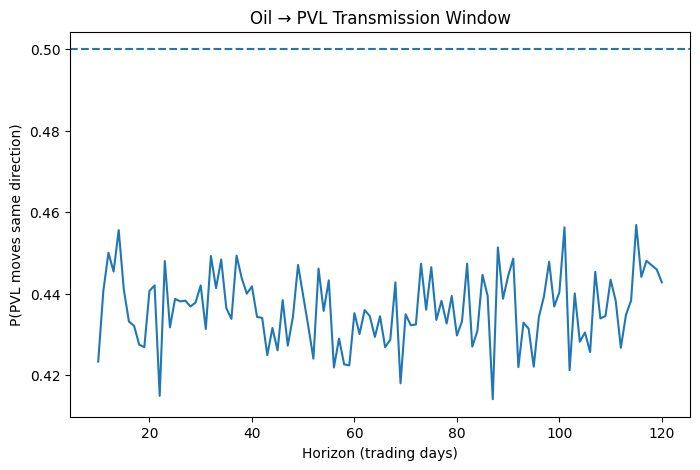

In [29]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ["USO", "PVL"]
period = "10y"

# horizon window (~2–4 months)
h_start = 10
h_end = 120

# ─────────────────────────
# DOWNLOAD DATA
# ─────────────────────────

prices = pd.DataFrame()

for t in tickers:
    df = yf.download(
        t,
        period=period,
        auto_adjust=True,
        progress=False,
        threads=False
    )
    prices[t] = df["Close"]

prices = prices.dropna()

returns = np.log(prices).diff().dropna()

uso = returns["USO"]

# ─────────────────────────
# TEST HORIZON RANGE
# ─────────────────────────

results = []

for h in range(h_start, h_end + 1):

    pvl_future = returns["PVL"].shift(-h)

    df = pd.DataFrame({
        "uso": uso,
        "pvl_future": pvl_future
    }).dropna()

    same_dir = np.mean(
        np.sign(df["uso"]) == np.sign(df["pvl_future"])
    )

    results.append(same_dir)

horizons = np.arange(h_start, h_end + 1)

# ─────────────────────────
# PLOT TRANSMISSION CURVE
# ─────────────────────────

plt.figure(figsize=(8,5))

plt.plot(horizons, results)

plt.axhline(0.5, linestyle="--")

plt.xlabel("Horizon (trading days)")
plt.ylabel("P(PVL moves same direction)")
plt.title("Oil → PVL Transmission Window")

plt.show()